# Notebook 06 — Monte Carlo Retrieval Simulation

## Overview
Real satellite retrieval algorithms are validated using **end-to-end Monte Carlo (MC) simulations**: synthetic observations are generated under thousands of different atmospheric conditions, the retrieval algorithm is run on each, and the resulting error statistics characterise the mission performance.

This notebook demonstrates three Monte Carlo experiments:

| Experiment | What varies | What it measures |
|---|---|---|
| **Noise Ensemble** | Instrument noise only | Retrieval *precision* (random error) |
| **XCO₂ Sweep** | True CO₂ concentration | Retrieval *linearity* and *bias* |
| **Random Scenes** | All parameters (P, T, albedo, SZA, SNR, XCO₂) | End-to-end mission performance |

## Statistical Framework
For N Monte Carlo trials:

$$\text{Bias} = \frac{1}{N}\sum_{i=1}^N (\hat{x}_i - x_i^{\text{true}})$$

$$\text{Precision} = \sqrt{\frac{1}{N}\sum_{i=1}^N (\hat{x}_i - x_i^{\text{true}} - \text{Bias})^2}$$

$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^N (\hat{x}_i - x_i^{\text{true}})^2}$$

For a well-calibrated retrieval: RMSE² ≈ Bias² + Precision²

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from hitran_model import hitran_cross_section, SYNTHETIC_CO2_LINES
from radiative_transfer import standard_atmosphere_profile, column_amount
from monte_carlo import (
    run_monte_carlo,
    plot_noise_ensemble,
    plot_xco2_sweep,
    plot_random_scene,
    plot_snr_sensitivity,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Spectral grid — slightly coarser for MC speed
nu = np.linspace(6210, 6270, 2000)
print(f'Spectral grid: {len(nu)} points  ({nu.min():.0f}–{nu.max():.0f} cm⁻¹)')

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

## Setup: Forward Model Functions

The MC runner needs two callables:
- `xsec_func(P, T)` → absorption cross section
- `N_col_func(P, T, xco2_ppm)` → CO₂ column amount

In [3]:
def xsec_func(P_Pa, T_K):
    """CO₂ absorption cross section at given P, T."""
    return hitran_cross_section(nu, SYNTHETIC_CO2_LINES, P_Pa, T_K)

def N_col_func(P_Pa, T_K, xco2_ppm):
    """CO₂ vertical column amount for given surface P, T, concentration."""
    profile = standard_atmosphere_profile(
        P_surface_Pa=P_Pa,
        T_surface_K=T_K,
        co2_vmr_ppm=xco2_ppm,
    )
    return column_amount(profile['number_density'], profile['layer_thickness_cm'])

# Quick check
xsec_test = xsec_func(101325.0, 288.0)
N_test    = N_col_func(101325.0, 288.0, 420.0)
print(f'Cross section peak: {xsec_test.max():.3e} cm²/molecule')
print(f'CO₂ column amount:  {N_test:.3e} molecules/cm²')

Cross section peak: 6.136e-23 cm²/molecule
CO₂ column amount:  1.122e+22 molecules/cm²


## Experiment 1 — Noise Ensemble

**Question:** Given a fixed atmosphere, how precisely can we retrieve XCO₂?

**Setup:** True XCO₂ = 430 ppm, 400 independent noise realisations at SNR = 250.

Running noise ensemble MC (N=400) …
  Sample 1/400 …
  Sample 101/400 …
  Sample 201/400 …
  Sample 301/400 …

Completed. 400/400 samples converged successfully.
Monte Carlo Summary  (N = 400)
  Bias      : -0.022 ppm
  Precision : 0.475 ppm
  RMSE      : 0.475 ppm
  Mean unc. : 0.468 ppm



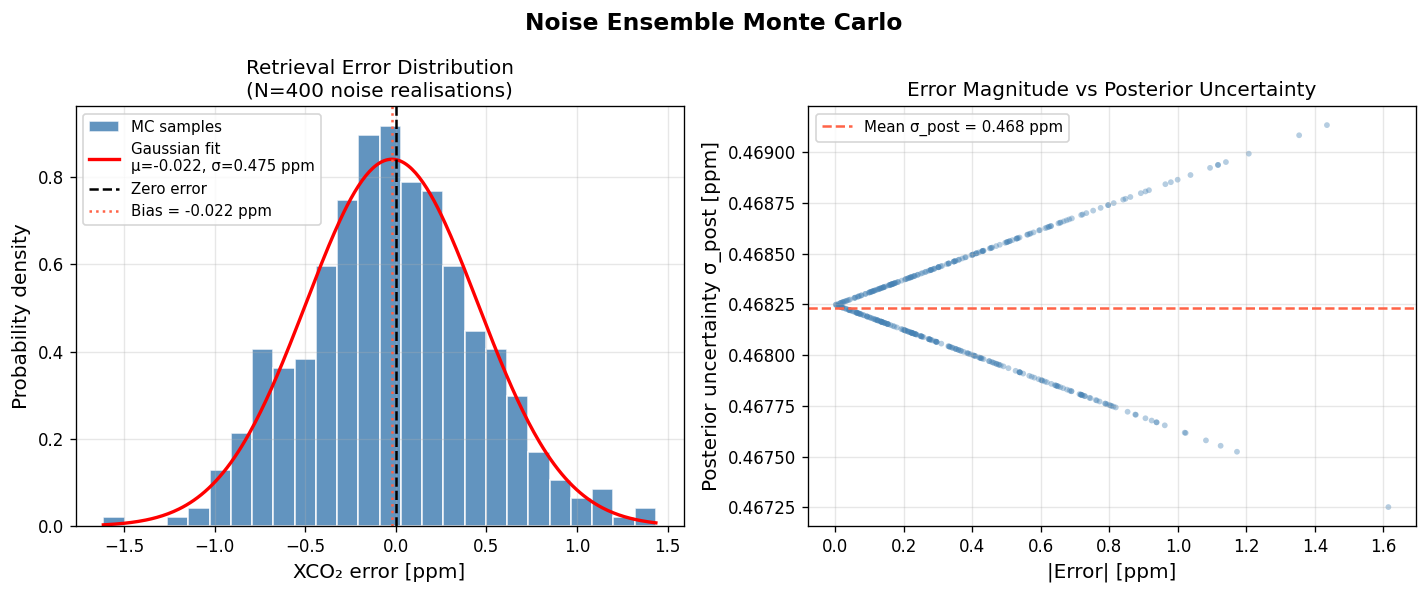

In [4]:
print('Running noise ensemble MC (N=400) …')
res_noise = run_monte_carlo(
    nu, xsec_func, N_col_func,
    n_samples=400,
    mode='noise_ensemble',
    xco2_fixed_ppm=430.0,
    xco2_prior_ppm=420.0,
    snr_fixed=250.0,
    sa=0.10,
    random_seed=42,
)

print(res_noise.summary())
plot_noise_ensemble(res_noise, savefig='../figures/06a_noise_ensemble.png')

### Interpretation
- The error histogram should be approximately Gaussian if the retrieval is well-behaved.
- The **bias** (mean error) reflects systematic errors — ideally < 0.1 ppm.
- The **precision** (σ of errors) reflects the random noise floor of the retrieval.
- The posterior uncertainty σ_post (from the OE formalism) should match the empirical precision.

## Experiment 2 — XCO₂ Sweep

**Question:** Is the retrieval linear across the full range of CO₂ concentrations?

**Setup:** True XCO₂ swept from 380 to 480 ppm. One retrieval per point (no noise averaging).

Running XCO₂ sweep MC (N=80) …
  Sample 1/80 …

Completed. 80/80 samples converged successfully.
Monte Carlo Summary  (N = 80)
  Bias      : +0.046 ppm
  Precision : 0.380 ppm
  RMSE      : 0.383 ppm
  Mean unc. : 0.390 ppm



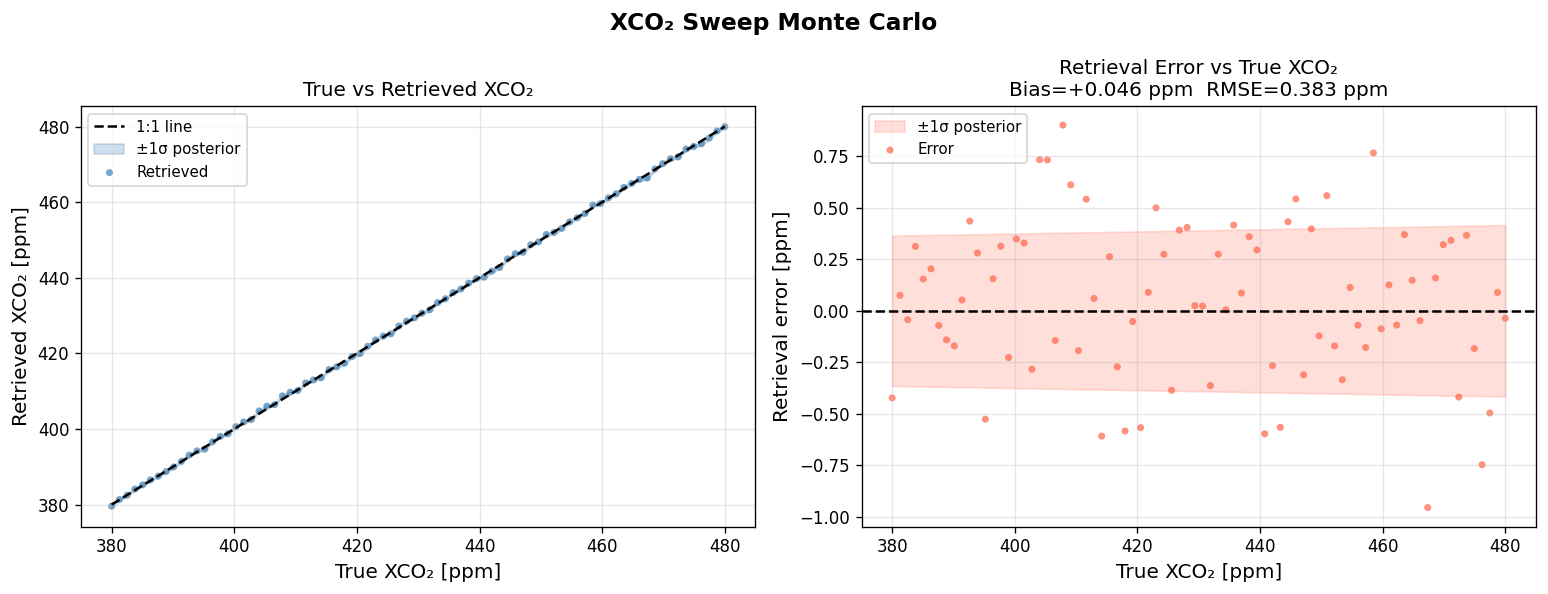

In [5]:
print('Running XCO₂ sweep MC (N=80) …')
res_sweep = run_monte_carlo(
    nu, xsec_func, N_col_func,
    n_samples=80,
    mode='xco2_sweep',
    xco2_min_ppm=380.0,
    xco2_max_ppm=480.0,
    xco2_prior_ppm=420.0,
    snr_fixed=300.0,
    sa=0.10,
    random_seed=0,
)

print(res_sweep.summary())
plot_xco2_sweep(res_sweep, savefig='../figures/06b_xco2_sweep.png')

### Interpretation
- Points near the diagonal → good linearity.
- Systematic pull toward the prior (420 ppm) at extremes is expected — this is the regularisation effect.
- The ±1σ envelope should bracket the 1:1 line within the retrieval uncertainty.

## Experiment 3 — Random Scene Ensemble

**Question:** How does the retrieval perform across the full range of real-world atmospheric states?

**Setup:** All geophysical parameters are randomly drawn from physically motivated distributions.

| Parameter | Distribution |
|---|---|
| XCO₂ | N(420, 15) ppm |
| Surface albedo | Uniform(0.05, 0.40) |
| Solar zenith angle | Uniform(10°, 70°) |
| Surface temperature | N(288, 12) K |
| Surface pressure | N(101325, 2000) Pa |
| SNR | Uniform(150, 400) |

Running random scene MC (N=500) — this may take ~2 minutes …
  Sample 1/500 …
  Sample 101/500 …
  Sample 201/500 …
  Sample 301/500 …
  Sample 401/500 …

Completed. 500/500 samples converged successfully.
Monte Carlo Summary  (N = 500)
  Bias      : +0.020 ppm
  Precision : 0.464 ppm
  RMSE      : 0.464 ppm
  Mean unc. : 0.433 ppm



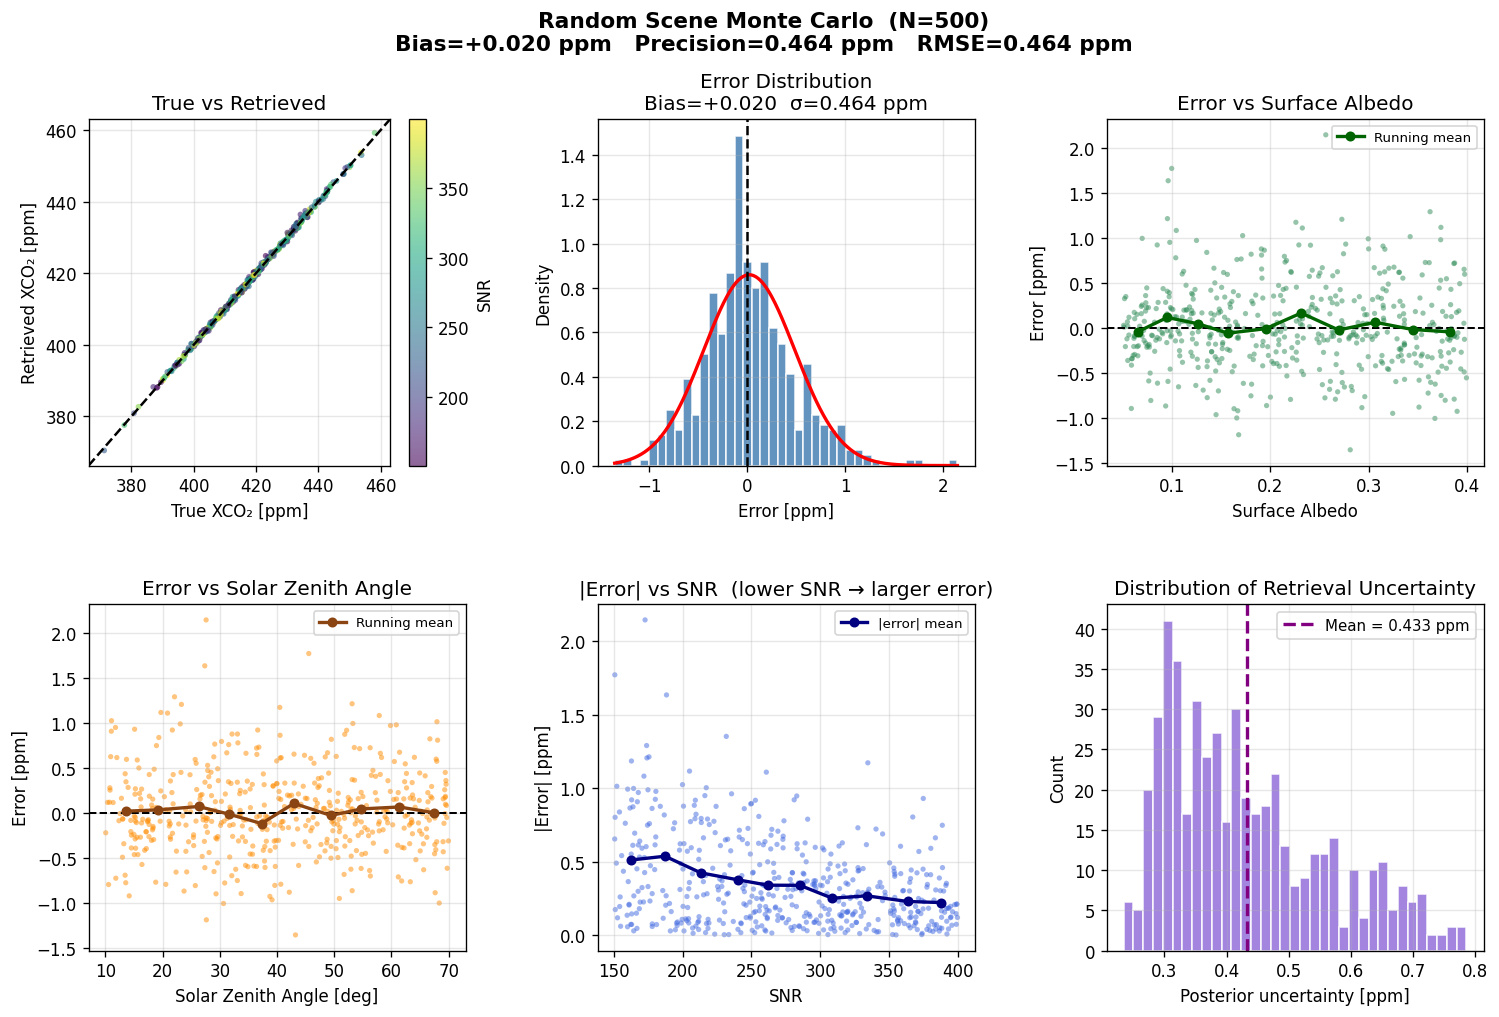

In [6]:
print('Running random scene MC (N=500) — this may take ~2 minutes …')
res_random = run_monte_carlo(
    nu, xsec_func, N_col_func,
    n_samples=500,
    mode='random_scene',
    xco2_prior_ppm=420.0,
    xco2_mean_ppm=420.0,
    xco2_std_ppm=15.0,
    snr_min=150.0,
    snr_max=400.0,
    sa=0.10,
    random_seed=7,
)

print(res_random.summary())
plot_random_scene(res_random, savefig='../figures/06c_random_scene.png')

## Experiment 4 — SNR Sensitivity Study

**Question:** How does instrument sensitivity (SNR) control retrieval quality?

This shows the **instrument design trade-off**: higher SNR → better CO₂ precision, but requires more photons (larger aperture, longer integration time, etc.).

Running SNR sensitivity study …
  SNR = 50 …
  SNR = 100 …
  SNR = 150 …
  SNR = 200 …
  SNR = 300 …
  SNR = 400 …
  SNR = 500 …


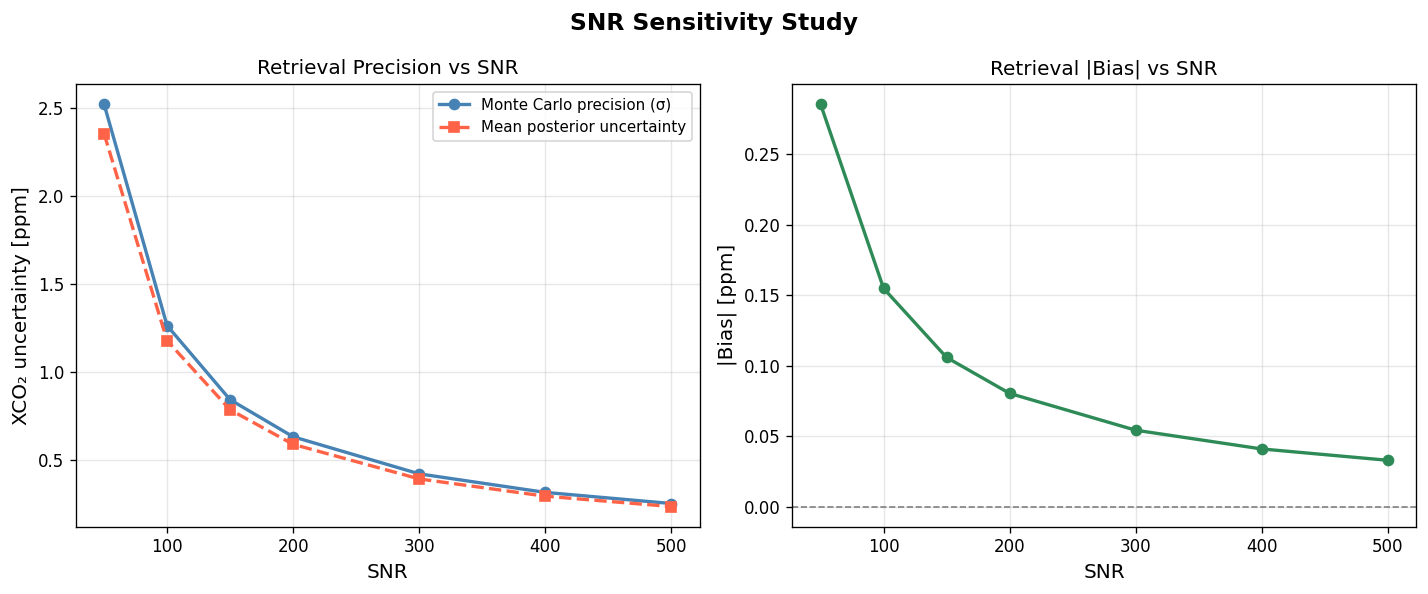

In [7]:
snr_values = [50, 100, 150, 200, 300, 400, 500]

print('Running SNR sensitivity study …')
plot_snr_sensitivity(
    nu, xsec_func, N_col_func,
    snr_values=snr_values,
    xco2_true_ppm=435.0,
    xco2_prior_ppm=420.0,
    n_trials_per_snr=150,
    sa=0.10,
    random_seed=99,
    savefig='../figures/06d_snr_sensitivity.png',
)

## Experiment 5 — Prior Constraint Sensitivity

**Question:** How much does the a priori constraint affect the retrieval?

The a priori uncertainty `sa` controls how much we trust the prior vs the measurement.
A tight prior (`sa` small) regularises more but can introduce bias when the truth departs from the prior.

  sa=0.02: bias=-0.014 ppm  precision=0.487 ppm
  sa=0.05: bias=+0.040 ppm  precision=0.488 ppm
  sa=0.10: bias=+0.047 ppm  precision=0.488 ppm
  sa=0.20: bias=+0.049 ppm  precision=0.488 ppm
  sa=0.40: bias=+0.050 ppm  precision=0.488 ppm


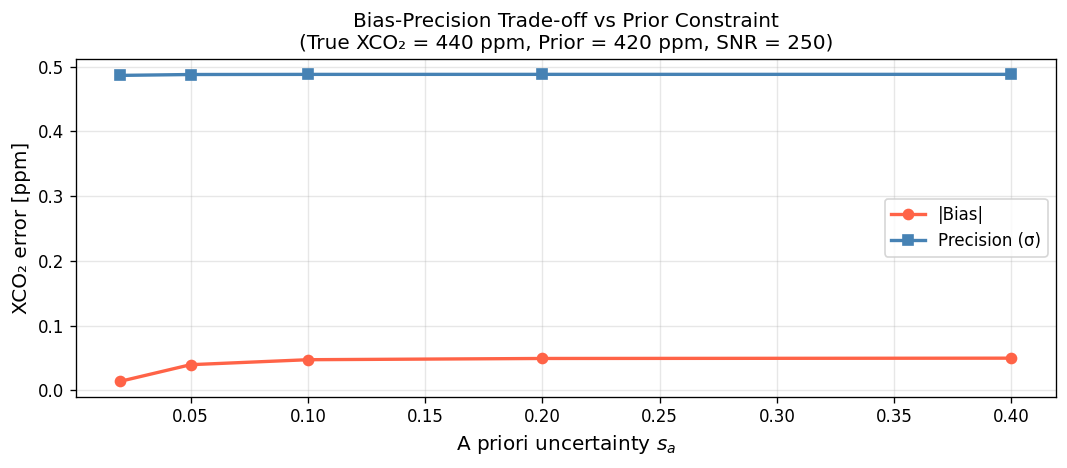

In [8]:
sa_values  = [0.02, 0.05, 0.10, 0.20, 0.40]
prior_biases    = []
prior_precisions = []

for sa_val in sa_values:
    res = run_monte_carlo(
        nu, xsec_func, N_col_func,
        n_samples=200, mode='noise_ensemble',
        xco2_fixed_ppm=440.0,   # 20 ppm from prior
        xco2_prior_ppm=420.0,
        snr_fixed=250.0, sa=sa_val,
        random_seed=1, verbose=False,
    )
    prior_biases.append(res.bias)
    prior_precisions.append(res.precision)
    print(f'  sa={sa_val:.2f}: bias={res.bias:+.3f} ppm  precision={res.precision:.3f} ppm')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sa_values, np.abs(prior_biases), 'o-', color='tomato', lw=2, label='|Bias|')
ax.plot(sa_values, prior_precisions,     's-', color='steelblue', lw=2, label='Precision (σ)')
ax.set_xlabel('A priori uncertainty $s_a$', fontsize=12)
ax.set_ylabel('XCO₂ error [ppm]', fontsize=12)
ax.set_title('Bias-Precision Trade-off vs Prior Constraint\n'
             '(True XCO₂ = 440 ppm, Prior = 420 ppm, SNR = 250)', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/06e_prior_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation
- **Small `sa`** (tight prior): low precision variance, but high bias because the retrieval is pulled toward the prior.
- **Large `sa`** (loose prior): lower bias, but noisier retrieval — the measurement alone must constrain XCO₂.
- This is the **bias-variance trade-off** inherent in all regularised inversions.

---

## Summary

| Experiment | Key Result |
|---|---|
| Noise ensemble | Gaussian errors, precision set by SNR and CO₂ sensitivity |
| XCO₂ sweep | Approximately linear retrieval; prior pull at extremes |
| Random scenes | Error depends on albedo, SZA, SNR — not XCO₂ itself |
| SNR sensitivity | Precision ∝ 1/SNR — instrument design directly sets CO₂ accuracy |
| Prior sensitivity | Bias-variance trade-off — loose prior preferred when scene diversity is high |

These experiments replicate the core validation methodology used by OCO-2, MicroCarb, and GOSAT science teams before launch and during on-orbit calibration.

# Loading data directly from mc_data folder

In [9]:
import sys, os

# ── Add src/ to path (works from notebooks/ subfolder) ──
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
MC_DATA_DIR  = os.path.join(PROJECT_ROOT, "mc_data")

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root : {PROJECT_ROOT}")
print(f"src/         : {SRC_DIR}")
print(f"mc_data/     : {MC_DATA_DIR}")

Project root : /home/arun/Documents/co2_measurements
src/         : /home/arun/Documents/co2_measurements/src
mc_data/     : /home/arun/Documents/co2_measurements/mc_data
